# Experimento 2 — Diseño Factorial 2×2 con 5-Fold CV

Aisla el efecto de cada componente del pipeline con validación cruzada robusta.

| Modelo | Normalización | Aumento |
|:------:|:-------------:|:-------:|
| A      | ✗             | ✗       |
| B      | ✗             | ✓       |
| C      | ✓             | ✗       |
| D      | ✓             | ✓       |

**Análisis factorial:**
- Efecto normalización = ((C−A) + (D−B)) / 2  
- Efecto aumento       = ((B−A) + (D−C)) / 2  
- Efecto interacción   = (D−C) − (B−A)

**Método:** 5-Fold Stratified CV con Wilson CI 95% (mismo protocolo que exp_ablacion).  
**Ventaja vs split único:** promedia 153 muestras evaluadas → resultados estables y reproducibles.

In [1]:
# Determinismo estricto — debe ejecutarse ANTES de importar TensorFlow
import os
os.environ['PYTHONHASHSEED']         = '42'
os.environ['TF_DETERMINISTIC_OPS']   = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['CUDA_VISIBLE_DEVICES']   = ''
os.environ['TF_ENABLE_ONEDNN_OPTS']  = '0'   # fuerza CPU para máximo determinismo
print('Determinismo activado (CPU forzado)')

Determinismo activado (CPU forzado)


In [ ]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from utils.config import N_FRAMES, N_KEYPOINTS, DATA_DIR, CSV_TOP35, KEYPOINTS_DIR
from utils.preprocessing import normalizar_hombros
from utils.augmentation import aumentar_secuencia
from utils.model import construir_lstm, callbacks_entrenamiento
from utils.experiment_utils import fijar_semillas, wilson_ci, dividir_train_val as _dividir

SALIDA_DIR = os.path.join(DATA_DIR, 'experimentos', 'exp2_factorial', 'salidas')
os.makedirs(SALIDA_DIR, exist_ok=True)

N_FOLDS    = 5
MAX_EPOCHS = 150
SEED       = 42
VAL_RATIO  = 0.15
BATCH      = 16
HP = dict(lr=0.001, dropout=0.5, regularizacion=0.005, capa_densa=False)

print(f'Directorio de salida: {SALIDA_DIR}')


## Utilidades

In [3]:
def dividir_val(X_tr, y_tr, fold):
    return _dividir(X_tr, y_tr, seed=SEED + fold, val_ratio=VAL_RATIO)


def entrenar_fold(fold, X_tr, y_tr, X_val, y_val, X_test, y_test, n_clases):
    fijar_semillas(SEED + fold)
    model = construir_lstm(n_clases, **HP)
    hist = model.fit(
        X_tr, to_categorical(y_tr, n_clases),
        validation_data=(X_val, to_categorical(y_val, n_clases)),
        epochs=MAX_EPOCHS, batch_size=BATCH,
        callbacks=callbacks_entrenamiento(patience_stop=20, patience_lr=8),
        verbose=0,
    )
    h       = hist.history
    acc_key = 'accuracy' if 'accuracy' in h else 'categorical_accuracy'
    pred    = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc     = accuracy_score(y_test, pred)
    ep      = len(h[acc_key])
    tf.keras.backend.clear_session()
    return acc, ep, pred

print('Utilidades definidas.')


Utilidades definidas.


## Carga de datos

In [4]:
df      = pd.read_csv(CSV_TOP35)
clases  = sorted(df['glosa'].unique())
idx_map = {c: i for i, c in enumerate(clases)}
n_clases = len(clases)

X_all, y_all = [], []
omitidos = 0
for _, row in df.iterrows():
    npy = os.path.join(KEYPOINTS_DIR, f"{row['video_id']}.npy")
    if not os.path.exists(npy): omitidos += 1; continue
    kp = np.load(npy)
    if kp.shape != (N_FRAMES, N_KEYPOINTS): omitidos += 1; continue
    X_all.append(kp); y_all.append(idx_map[row['glosa']])
if omitidos: print(f'  [AVISO] {omitidos} archivos omitidos')
X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)

print(f'Dataset: {len(X_all)} muestras | {n_clases} clases')

Dataset: 153 muestras | 35 clases


## Construcción de condiciones por fold

In [5]:
def construir_datos(X_all, y_all, idx_trainval, idx_test, norm, aug, fold):
    """
    norm=False, aug=False → Modelo A (baseline)
    norm=False, aug=True  → Modelo B (solo aumento)
    norm=True,  aug=False → Modelo C (solo normalización)
    norm=True,  aug=True  → Modelo D (pipeline completo)
    Regla de no-leakage: aumento solo en train, nunca en val/test.
    """
    X_tv = X_all[idx_trainval].copy()
    y_tv = y_all[idx_trainval]
    X_te = X_all[idx_test].copy()
    y_te = y_all[idx_test]

    if norm:
        X_tv = np.array([normalizar_hombros(x) for x in X_tv], dtype=np.float32)
        X_te = np.array([normalizar_hombros(x) for x in X_te], dtype=np.float32)

    X_tr, y_tr, X_val, y_val = dividir_val(X_tv, y_tv, fold)

    if aug:
        X_aug, y_aug = [], []
        for xi, yi in zip(X_tr, y_tr):
            for v in aumentar_secuencia(xi):
                X_aug.append(v); y_aug.append(yi)
        X_tr = np.array(X_aug, dtype=np.float32)
        y_tr = np.array(y_aug, dtype=np.int32)

    return X_tr, y_tr, X_val, y_val, X_te, y_te

CONDICIONES = {
    'A': dict(norm=False, aug=False),
    'B': dict(norm=False, aug=True),
    'C': dict(norm=True,  aug=False),
    'D': dict(norm=True,  aug=True),
}
DESCRIPCIONES = {
    'A': 'sin norm / sin aumento (baseline)',
    'B': 'sin norm / con aumento',
    'C': 'con norm / sin aumento',
    'D': 'con norm / con aumento (pipeline completo)',
}
print('Condiciones definidas.')

Condiciones definidas.


## Ejecución 5-Fold por condición

In [6]:
print('='*65)
print('FACTORIAL 2×2 — 5-Fold Stratified CV')
print('='*65)

resultados = {c: [] for c in CONDICIONES}
all_pred   = {c: [] for c in CONDICIONES}
all_true   = []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (idx_trainval, idx_test) in enumerate(skf.split(X_all, y_all)):
    print(f'\n--- FOLD {fold+1}/{N_FOLDS} ---')
    fold_true = y_all[idx_test].tolist()

    for cond, params in CONDICIONES.items():
        X_tr, y_tr, X_val, y_val, X_te, y_te = construir_datos(
            X_all, y_all, idx_trainval, idx_test,
            norm=params['norm'], aug=params['aug'], fold=fold
        )
        acc, ep, pred = entrenar_fold(fold, X_tr, y_tr, X_val, y_val, X_te, y_te, n_clases)
        factor = f'x{len(X_tr)//len(idx_trainval)}' if params['aug'] else f'{len(X_tr)} muestras'
        print(f'  {cond} ({DESCRIPCIONES[cond][:25]}): acc={acc*100:.1f}%  ep={ep}  train={factor}')

        resultados[cond].append({'fold': fold+1, 'condicion': cond,
                                  'accuracy': round(acc, 4), 'epocas': ep,
                                  'n_train': len(X_tr), 'n_test': len(X_te)})
        all_pred[cond].extend(pred.tolist())

    all_true.extend(fold_true)

print('\n✓ Cross-validation completada.')

FACTORIAL 2×2 — 5-Fold Stratified CV

--- FOLD 1/5 ---


C:\Users\dell\miniconda3\envs\senas_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Epoch 63: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 84: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 93: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


...


Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Restoring model weights from the end of the best epoch: 32.


Epoch 52: early stopping


  D (con norm / con aumento (p): acc=53.3%  ep=52  train=x5

✓ Cross-validation completada.


## Estadísticas y análisis factorial

In [7]:
y_true_arr = np.array(all_true)
medias = {c: np.mean([r['accuracy'] for r in resultados[c]]) for c in CONDICIONES}

# Efectos factoriales
ef_norm  = ((medias['C'] - medias['A']) + (medias['D'] - medias['B'])) / 2
ef_aug   = ((medias['B'] - medias['A']) + (medias['D'] - medias['C'])) / 2
interacc = (medias['D'] - medias['C']) - (medias['B'] - medias['A'])

print(f"{'='*65}")
print(f"  RESUMEN FACTORIAL 2×2   (N={len(y_true_arr)} muestras evaluadas)")
print(f"{'='*65}")
print(f"  {'Cond':<5} {'Media':>7} {'Std':>6}  {'IC 95%':>18}  Descripción")
print(f"  {'-'*70}")

resumen_filas = []
for cond in CONDICIONES:
    accs  = [r['accuracy'] for r in resultados[cond]]
    preds = np.array(all_pred[cond])
    ci    = wilson_ci(int((preds == y_true_arr).sum()), len(y_true_arr))
    print(f"  {cond:<5} {np.mean(accs)*100:>6.1f}%"
          f"{np.std(accs)*100:>5.1f}%"
          f"  [{ci[0]*100:.1f}%, {ci[1]*100:.1f}%]"
          f"  {DESCRIPCIONES[cond]}")
    resumen_filas.append({
        'condicion': cond, 'descripcion': DESCRIPCIONES[cond],
        'acc_media': round(np.mean(accs), 4),
        'acc_std':   round(np.std(accs), 4),
        'ci95_low':  ci[0], 'ci95_high': ci[1],
        'n_total':   len(y_true_arr),
    })

print(f"\n  TABLA FACTORIAL 2×2")
print(f"  {'':20}  Sin aumento  Con aumento")
print(f"  {'Sin normalización':20}  {medias['A']*100:>8.1f}%   {medias['B']*100:>8.1f}%")
print(f"  {'Con normalización':20}  {medias['C']*100:>8.1f}%   {medias['D']*100:>8.1f}%")
print(f"\n  Efecto puro normalización: {ef_norm*100:+.1f} pp")
print(f"  Efecto puro aumento:       {ef_aug*100:+.1f} pp")
print(f"  Efecto de interacción:     {interacc*100:+.1f} pp  "
      f"({'sinergia' if interacc > 0 else 'redundancia'})")

  RESUMEN FACTORIAL 2×2   (N=153 muestras evaluadas)
  Cond    Media    Std              IC 95%  Descripción
  ----------------------------------------------------------------------
  A       40.4%  7.9%  [33.1%, 48.4%]  sin norm / sin aumento (baseline)
  B       41.1%  9.2%  [33.7%, 49.1%]  sin norm / con aumento
  C       41.8%  7.4%  [34.3%, 49.8%]  con norm / sin aumento
  D       50.3%  8.2%  [42.5%, 58.1%]  con norm / con aumento (pipeline completo)

  TABLA FACTORIAL 2×2
                        Sin aumento  Con aumento
  Sin normalización         40.4%       41.1%
  Con normalización         41.8%       50.3%

  Efecto puro normalización: +5.3 pp
  Efecto puro aumento:       +4.6 pp
  Efecto de interacción:     +7.8 pp  (sinergia)


## Guardar resultados

In [8]:
todos = []
for cond in CONDICIONES:
    todos.extend(resultados[cond])

pd.DataFrame(todos).to_csv(
    os.path.join(SALIDA_DIR, 'resultados_factorial_5fold.csv'), index=False, encoding='utf-8-sig')

df_resumen = pd.DataFrame(resumen_filas)
df_resumen.to_csv(
    os.path.join(SALIDA_DIR, 'comparativa_factorial_5fold.csv'), index=False, encoding='utf-8-sig')

pd.DataFrame({
    'efecto':    ['normalización', 'aumento', 'interacción'],
    'valor_pp':  [ef_norm*100, ef_aug*100, interacc*100],
    'tipo':      ['principal', 'principal', 'sinergia' if interacc > 0 else 'redundancia'],
}).to_csv(os.path.join(SALIDA_DIR, 'efectos_aislados_5fold.csv'), index=False, encoding='utf-8-sig')

print(f'Archivos guardados en: {SALIDA_DIR}/')
display(df_resumen)

Archivos guardados en: C:\Users\dell\Documents\TIC\Codigo_TIC\experimentos\exp2_factorial/


,condicion,descripcion,acc_media,acc_std,ci95_low,ci95_high,n_total
0,A,sin norm / sin aumento (baseline),0.4043,0.0792,0.3307,0.4844,153
1,B,sin norm / con aumento,0.4110,0.0920,0.3369,0.4910,153
2,C,con norm / sin aumento,0.4181,0.0739,0.3431,0.4975,153
3,D,con norm / con aumento (pipeline completo),0.5030,0.0817,0.4249,0.5814,153


## Visualización

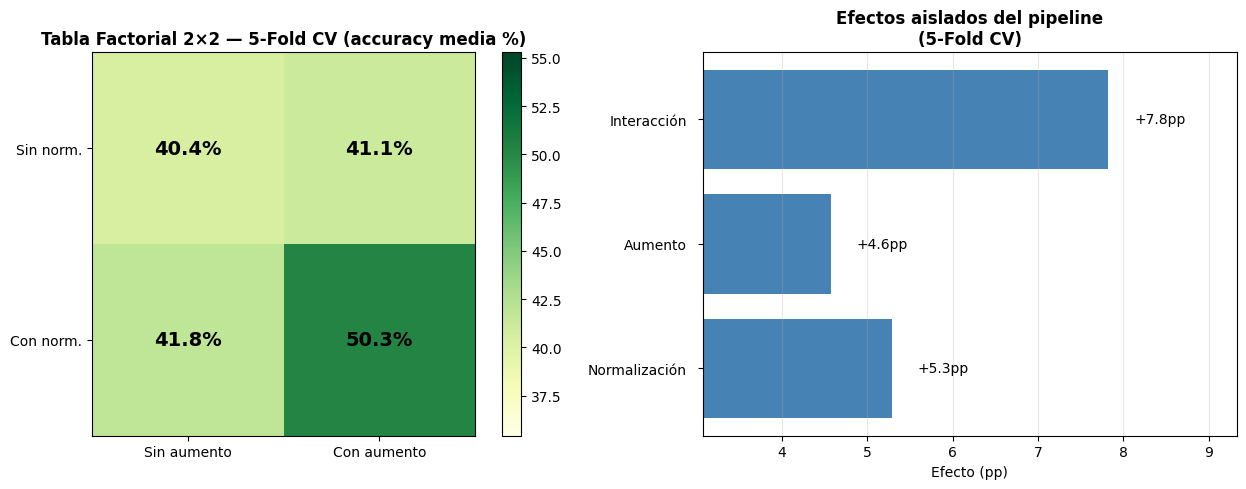

Figura guardada.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap factorial
ax = axes[0]
data = np.array([[medias['A']*100, medias['B']*100],
                  [medias['C']*100, medias['D']*100]])
im = ax.imshow(data, cmap='YlGn', vmin=data.min()-5, vmax=data.max()+5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Sin aumento', 'Con aumento'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Sin norm.', 'Con norm.'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{data[i,j]:.1f}%', ha='center', va='center',
                fontsize=14, fontweight='bold')
ax.set_title('Tabla Factorial 2×2 — 5-Fold CV (accuracy media %)', fontweight='bold')
plt.colorbar(im, ax=ax)

# Efectos aislados
ax2 = axes[1]
efectos = ['Normalización', 'Aumento', 'Interacción']
valores = [ef_norm*100, ef_aug*100, interacc*100]
colores = ['steelblue' if v >= 0 else 'tomato' for v in valores]
ax2.barh(efectos, valores, color=colores)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Efecto (pp)')
ax2.set_title('Efectos aislados del pipeline\n(5-Fold CV)', fontweight='bold')
ax2.grid(True, axis='x', alpha=0.3)
margen = max(1.5, (max(valores) - min(valores)) * 0.35)
ax2.set_xlim(min(valores) - margen, max(valores) + margen)
ax2.tick_params(axis='y', pad=8)
for i, v in enumerate(valores):
    ax2.text(v + (0.3 if v >= 0 else -0.3), i, f'{v:+.1f}pp',
             va='center', ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.savefig(os.path.join(SALIDA_DIR, 'factorial_2x2_5fold.png'), dpi=150)
plt.show()
print('Figura guardada.')